## Import all the required modules

In [ ]:
import numpy as np
from scipy.integrate import  odeint
import matplotlib.pyplot as plt
# import importlib
import forced_eccentricity
# importlib.reload(forced_eccentricity)

<module 'forced_eccentricity' from '/Users/sergiogomes/Documents/PostDoc/V1298Tau/GitHub/forced_eccentricity.py'>

## Declaration of the physical properties of the system

In [2]:
global G, AU, R_sun, R_earth, M_earth

## Constants

G = 4*np.pi**2
AU = 149597870.7
R_Sun = 696340/AU
R_earth = 6378/AU
R_jupiter = 71492/AU
M_earth = 3.003e-6
M_jupiter = 9.547919e-4
M_sun = 1.989e30

## System properties

P_Star = 2.91/365.25
w_Star  = 2*np.pi/P_Star
mass_Star = 1.26 
R_star=1.43*R_Sun #(± 0.03)

P=np.array([ 8.249164, 12.401394, 24.140006, 48.677714])/365.25

e0 = np.array([ 0.94, 0.87, 0.79, 1.24]) * 0.01   
e0_upper = np.array([ 0.94, 0.87, 0.79+0.41, 1.24]) * 0.01   
e0_lower = np.array([ 0.0, 0.0, 0.79-0.41, 0]) * 0.01         

mass = np.array([ 4.7 , 6.0, 13.1, 15.3])*M_earth   
mass_upper = np.array([ 4.7 + 0.6 , 6.0 + 0.7, 13.1 + 5.3, 15.3 + 4.2])*M_earth    # Upper limits for the mass
mass_lower = np.array([ 4.7 - 0.6 , 6.0 - 0.7, 13.1 - 5.3, 15.3 - 4.2])*M_earth    # Upper limits for the mass

radius=np.array([ 4.85,  7.25, 9.96, 11.17])*R_earth    

mu = G * (mass_Star + mass)
beta = mass * mass_Star / (mass + mass_Star)

a=(P**2*(mass_Star+mass))**(1/3)


planet=['c','d','b','e']

Q_P = 3.3e4
tau_P = P/(2* np.pi * Q_P)
k2_P = 0.5 # 0.1
tau_k2_P = tau_P*k2_P

k2_Star = 3e-2
Q_Star = 10**(5.7) * 2/3 * k2_Star
Q_Star = 1e6 * 2/3 * k2_Star
tau_Star = P_Star / ( 4 * np.pi * Q_Star)

tau_k2_Star=tau_Star*k2_Star


# radius=np.array([ 4.85,  7.25, 9.96, 11.17])*R_earth  

radius_up   = np.array([ 4.85+0.17,  7.25+0.18, 9.96+0.22,11.17+0.61])*R_earth      
radius_down = np.array([ 4.85-0.17,  7.25-0.18, 9.96-0.22, 11.17-0.61])*R_earth    

radius_sikup=np.array([ 5.24+0.24, 6.34+0.3, 9.95+0.37,9.50])*R_earth         # Sikora values
radius_sikdown=np.array([ 5.24-0.23, 6.34-0.3,9.95-0.35, 9.50])*R_earth         # Sikora values


# mass = np.array([ 4.7 , 6.0, 13.1, 15.3])*M_earth
# mass_up    = np.array([ 4.7+0.6 , 6.0+0.7,13.1+5.3, 15.3+4.2])*M_earth
# mass_down  = np.array([ 4.7-0.6 , 6.0-0.7,13.1-5.3, 15.3-4.2])*M_earth

mass_up = mass_upper
mass_down = mass_lower


mass_sikup = np.array([ 19.8+9.3 , 36,159, 210])*M_earth
mass_sikdown = np.array([ 19.8-8.9 , 36-35.9,159-158.9, 210])*M_earth


P=np.array([ 8.249164, 12.401394, 24.140006, 48.677714])/365.25
a=(P**2*(mass_Star+mass))**(1/3)
e0 = np.array([ 0.79, 0.94, 0.87, 1.24]) * 0.01  
esik = np.array([ 0.17, 0.3, 0.12 , 0.25]) *0.1
esik = np.array([ 0.79, 0.94, 0.87, 1.24]) * 0.01   

R_star_up   = R_star + 0.03
R_star_down = R_star - 0.03

R_star_sik = 1.355*R_Sun


## Compute the period ratios of the planets

In [3]:
for i in range(1,4): 
    print(r"P{}/P{} = {:.4f}".format( planet[-i] , planet[-i-1], P[-i]/P[-i-1]))
print('')
for i in range(1,3): 
    print(r"P{}/P{} = {:.4f}".format( planet[-i] , planet[-i-2], P[-i]/P[-i-2]))
print('')
for i in range(1,2): 
    print(r"P{}/P{} = {:.4f}".format( planet[-i] , planet[-i-3], P[-i]/P[-i-3]))

Pe/Pb = 2.0165
Pb/Pd = 1.9466
Pd/Pc = 1.5034

Pe/Pd = 3.9252
Pb/Pc = 2.9264

Pe/Pc = 5.9009


# Forced eccentricities

Integrator: whfast dt (yr): 0.0001
Total integration time: 5.00e+01 yr, output every 1000.0 yr
[0.0053897  0.00460271 0.00399399 0.0009336 ]


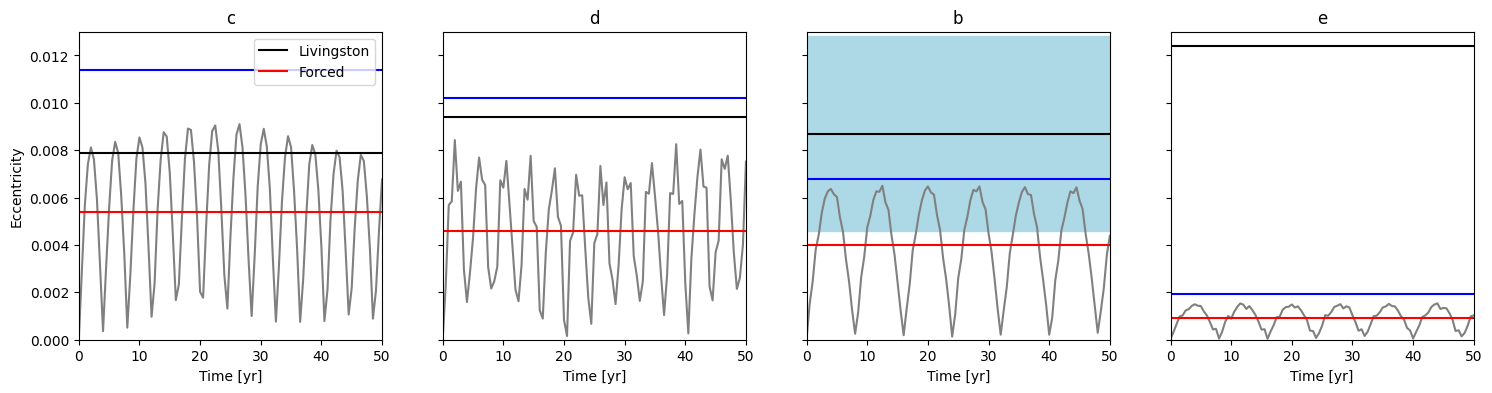

In [4]:
T_total = 5e1            
n_points = 1e2
time, semi,e = forced_eccentricity.forced(T_total, n_points)

e_mean = np.mean(e,axis=1)
print(e_mean)


fig, axs = plt.subplots(1,4, figsize=(18,4), sharey=True)
for i,ax in enumerate(axs):
    ax.plot( time , e[i,:], color = 'grey', linestyle = '-')
    ax.axhline(e0[i], color = 'black', label='Livingston')
    ax.axhline(e_mean[i], color = 'red', label='Forced')
    ax.set( title = planet[i], ylim=[0,0.013], xlim=[0,time[-1]], xlabel="Time [yr]")

axs[2].fill_between(time, e0[2]-0.41*0.01, e0[2]+0.41*0.01, color = 'lightblue')
axs[0].set(ylabel = 'Eccentricity')
axs[0].legend()

axs[0].axhline(e_mean[0]+0.006, color = 'blue')
axs[1].axhline(e_mean[1]+0.0056, color = 'blue')
axs[2].axhline(e_mean[2]+0.0028, color = 'blue')
axs[3].axhline(e_mean[3]+0.001, color = 'blue')

plt.show()

## Resonance check

Integrator: whfast 
dt: 0.001 (yr) 
Total integration time: 10000.0 yr


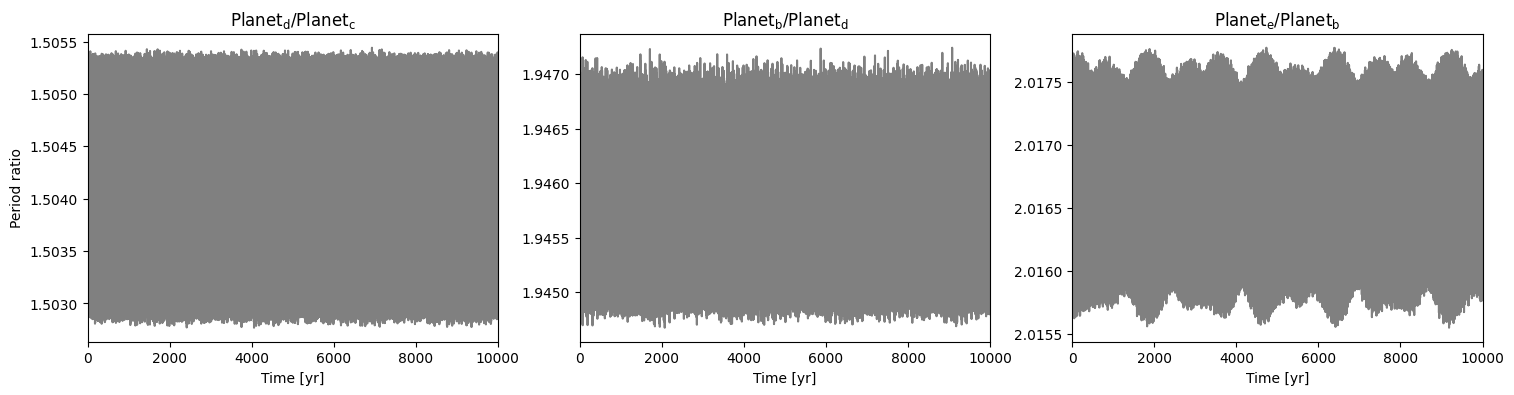

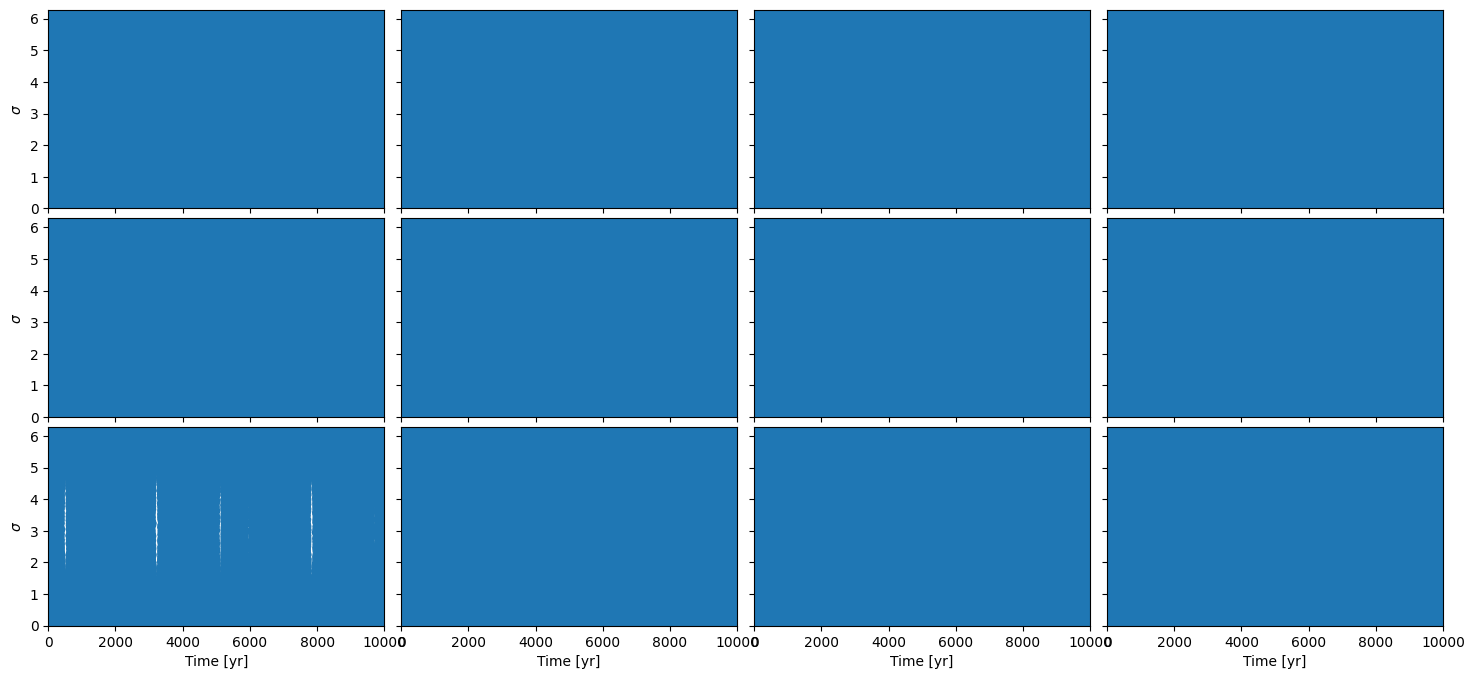

In [10]:

T_total = 1e4            # total integration time in years (1 Myr)
n_points = 1e6          # Number of values to output
time , semi , e, n, l, w, Omega = forced_eccentricity.resonance(T_total, n_points,e0)

P_evolution = np.zeros([4,len(time)])
for i in range(4): P_evolution[i,:] = np.sqrt( semi[i,:]**3 / (mass_Star+mass[i])) 


fig, axs = plt.subplots(1,3, figsize=(18,4))
for i,ax in enumerate(axs):
    ax.plot( time , P_evolution[i+1,:]/P_evolution[i,:], color = 'grey', linestyle = '-')
    ax.set( title = r'$\rm Planet_{} / Planet_{}$'.format(planet[i+1], planet[i]) ,
            xlim=[0,time[-1]],
            xlabel = 'Time [yr]')
axs[0].set( ylabel = 'Period ratio')

sigma = np.zeros([4, len(time)])    

fig, axs = plt.subplots(3,4, figsize=(18,8),sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# 3:2 between c and d
sigma[0,:] = ( 3 * l[1,:] - 2 * l[0,:] - w[0,:] )% (2*np.pi)
sigma[1,:] = ( 3 * l[1,:] - 2 * l[0,:] - w[1,:] )% (2*np.pi)
sigma[2,:] = ( 3 * l[1,:] - 2 * l[0,:] - Omega[0,:] )% (2*np.pi)
sigma[3,:] = ( 3 * l[1,:] - 2 * l[0,:] - Omega[1,:] ) % (2*np.pi)
for i,ax in enumerate(axs[0,:]):
    ax.plot( time , sigma[i,:], '.')
    ax.set( xlim=[0,time[-1]])

# 2:1 between d and b
sigma[0,:] = ( 2 * l[2,:] - 1 * l[1,:] - w[1,:] )% (2*np.pi)
sigma[1,:] = ( 2 * l[2,:] - 1 * l[1,:] - w[2,:] )% (2*np.pi)
sigma[2,:] = ( 2 * l[2,:] - 1 * l[1,:] - Omega[1,:] )% (2*np.pi)
sigma[3,:] = ( 2 * l[2,:] - 1 * l[1,:] - Omega[2,:] ) % (2*np.pi)
for i,ax in enumerate(axs[1,:]):
    ax.plot( time , sigma[i,:], '.')
    ax.set( xlim=[0,time[-1]])

# 2:1 between b and e
sigma[0,:] = ( 2 * l[3,:] - 1 * l[2,:] - w[2,:] )% (2*np.pi)
sigma[1,:] = ( 2 * l[3,:] - 1 * l[2,:] - w[3,:] )% (2*np.pi)
sigma[2,:] = ( 2 * l[3,:] - 1 * l[2,:] - Omega[2,:] )% (2*np.pi)
sigma[3,:] = ( 2 * l[3,:] - 1 * l[2,:] - Omega[3,:] ) % (2*np.pi)
for i,ax in enumerate(axs[2,:]):
    ax.plot( time , sigma[i,:], '.')
    ax.set( xlabel = 'Time [yr]', xlim=[0,time[-1]], ylim=[0,2*np.pi])

for ax in axs[:,0]: ax.set(ylabel = r'$\sigma$')   

# axs[0].legend()

plt.show()


## Normalized angular momentum

In [ ]:
def AMD(mass, mass_Star, P, e):
    inc = np.array([1,1,1,1])*1
    a=(P**2*(mass_Star+mass))**(1/3)
    angular_momentum_deficit =np.sum( mass * np.sqrt( a ) * ( 1 - np.sqrt( 1- e**2) *np.cos(inc*np.pi/180) ) )
    normalized_angular_momentum_deficit = angular_momentum_deficit / np.sum ( mass * np.sqrt( a ) )
    return normalized_angular_momentum_deficit

print('Mean:  {:.2e}'.format( AMD(mass, mass_Star, P, e0)) )
print('Upper: {:.2e}'.format( AMD(mass_upper, mass_Star+0.06, P, e0_upper)))
print('Lower: {:.2e}'.format( AMD(mass_lower, mass_Star-0.06, P, e0_lower)))

Mean:  2.09e-04
Upper: 2.21e-04
Lower: 1.54e-04


## Tidal functions

In [7]:
def f_functions(e):
    f_values=np.ones(5)

    f_values[0] = ( 1 + 3    * e**2 + 0.375  * e**4                                 ) / ( 1 - e**2 )**4.5 
    f_values[1] = ( 1 + 7.5  * e**2 + 5.625  * e**4 + 0.3125  * e**6                ) / ( 1 - e**2 )**6
    f_values[2] = ( 1 + 15.5 * e**2 + 31.875 * e**4 + 11.5625 * e**6 + 25/64 * e**8 ) / ( 1 - e**2 )**7.5
    f_values[3] = ( 1 + 1.5  * e**2 + 0.125  * e**4                                 ) / ( 1 - e**2 )**5
    f_values[4] = ( 1 + 3.75 * e**2 + 1.875  * e**4 + 5/64    * e**6                ) / ( 1 - e**2 )**6.5

    return f_values
########################################################################################################################

def large_K(tau_k2,mass,R,a):
    
    K = 3 * tau_k2 * G * mass**2 * R**5 / a**6
    return K

########################################################################################################################

def dadt(arg ,t , mass, rad0, tau_k2, wStar , theta, flag_eccentricity , flag_radius):
    
    a = arg[0]          # arg[0] = semi-major axis
    e = arg[1]          # arg[1] = eccentricity
    radius = arg[2:]    # arg[2] = R central body


    beta=mass[0]*mass[1]/sum(mass)

    f = f_functions(e)
  
    K = large_K( tau_k2 , mass[::-1] , radius , a )

    n = np.sqrt( G * ( sum(mass)) / a**3 )
    

    
    da_star = 2 * K[0] / ( beta * a ) * ( f[1] * wStar/n - f[2]) 
    da_planet = 2 * K[1] / ( beta * a ) * ( f[1]**2 / f[0] - f[2]) 
    da =  da_star + da_planet


    if flag_eccentricity: de = sum(9*K/(beta*a**2)*(11/18*f[3]*f[1]/f[0]-f[2]))*e
    else: de = 0  
    
    if flag_radius and t<1e7:
 
        timescale = -np.log(2/3)/1e7  # The fraction of the reduction (1/2)  in the amount of time (10 Myr)
        dR1 = -timescale * rad0 * np.exp( -timescale * t )
    else: dR1 = 0

    return np.array([da, de,  0, dR1])

########################################################################################################################

def a_MMR_reverse(aMMR, p, q, body_in, body_out):
    return ((p/(p+q))**2 * mu[body_in]/mu[body_out] )**(1/3) *aMMR

########################################################################################################################

def da_evolution(semi_evolution,planet, mass):
    
    tau_k2_P_evolution=np.array([ 2e-5 , 5e-7 , 1e-6 , 0 ]) * P / ( 2 * np.pi )
    tau_k2 = np.array([tau_k2_Star , tau_k2_P_evolution[planet]])

    mass_t = np.array([mass_Star , mass[planet]])
    
    wStar = 2*np.pi/P_Star
    
    da_planet = np.zeros(len(semi_evolution[:,0]))
    da_star   = np.zeros(len(semi_evolution[:,0]))


    for i in range(len(semi_evolution[:,0])):

        a = semi_evolution[i,0]
        e = semi_evolution[i,1]
        radius_t = np.array([R_star, semi_evolution[i,3]])

        beta = mass_Star * mass[planet] / ( mass_Star + mass[planet] )

        f_t= f_functions(e)
        
        K = large_K( tau_k2, mass_t[::-1] , radius_t , a )

        n = np.sqrt( G * (mass_Star+mass[planet])/ a **3)
        
        
        da_star[i]   = 2 * K[0] / (beta * a**2) * (f_t[1] * wStar/n - f_t[2]) * a 
        da_planet[i] = 2 * K[1] / (beta * a**2) * (f_t[1]**2/f_t[0] - f_t[2]) * a

    return da_star, da_planet
 
 ########################################################################################################################

## Radial shrinkage evolutionary track

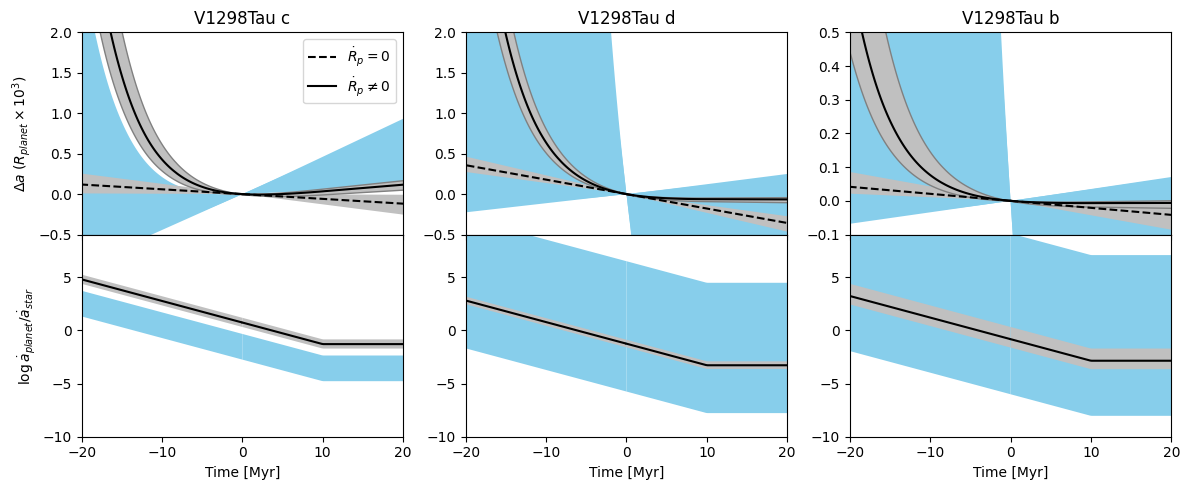

In [8]:
fig, ax = plt.subplots(2,3,sharex=True,figsize=(12,5))

tau_k2_P_evolution= tau_k2_P

t_init  = -20e6
t_final =  20e6

time_long=np.linspace(0,t_init,100)
time_long_axis=time_long*1e-6


order = [0,1,2]
 
planet_order_plot=['c','d','b','e']

#Define colors and alpha
color_line_main = 'k'
color_line_main_dash = 'k--'
color_fill_main = 'silver'
color_fill_dash_main = 'silver'
color_fill_dash_old = 'skyblue'
color_fill_old = 'skyblue'

alpha_fill_main = 1
alpha_fill_old  = 1

eflag = 0


for i in range(0,len(planet)-1):

    a_normalization=a[i]

    ######################## Past #############################
    # Mean value
    semi_evolution_ecc_past        = odeint(dadt, np.array([a[i], e0[i], R_star, radius[i]]), time_long, args=( np.array([mass_Star , mass[i]]),radius[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,0)) 
    semi_evolution_ecc_radius_past = odeint(dadt, np.array([a[i], e0[i], R_star, radius[i]]), time_long, args=( np.array([mass_Star , mass[i]]),radius[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,1))

    da_star_past , da_planet_past = da_evolution(semi_evolution_ecc_radius_past,i, mass)

    # Upper limit
    semi_evolution_ecc_past_up        = odeint(dadt, np.array([a[i], e0[i], R_star, radius_up[i]]), time_long, args=( np.array([mass_Star , mass_down[i]]),radius_up[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,0)) 
    semi_evolution_ecc_radius_past_up = odeint(dadt, np.array([a[i], e0[i], R_star, radius_up[i]]), time_long, args=( np.array([mass_Star , mass_down[i]]),radius_up[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,1))

    da_star_past_up , da_planet_past_up = da_evolution(semi_evolution_ecc_radius_past_up,i, mass_down)

    # Bottom limit
    semi_evolution_ecc_past_down        = odeint(dadt, np.array([a[i], e0[i], R_star, radius_down[i]]), time_long, args=( np.array([mass_Star , mass_up[i]]),radius_down[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,0)) 
    semi_evolution_ecc_radius_past_down = odeint(dadt, np.array([a[i], e0[i], R_star, radius_down[i]]), time_long, args=( np.array([mass_Star , mass_up[i]]),radius_down[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,1))

    da_star_past_down , da_planet_past_down = da_evolution(semi_evolution_ecc_radius_past_down,i, mass_up)

    # Sikora values up
    semi_evolution_ecc_past_sikup        = odeint(dadt, np.array([a[i], esik[i], R_star_sik, radius_sikup[i]]), time_long, args=( np.array([mass_Star , mass_sikdown[i]]),radius_sikup[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,0)) 
    semi_evolution_ecc_radius_past_sikup = odeint(dadt, np.array([a[i], esik[i], R_star_sik, radius_sikup[i]]), time_long, args=( np.array([mass_Star , mass_sikdown[i]]),radius_sikup[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,1)) 

    da_star_past_sikup , da_planet_past_sikup = da_evolution(semi_evolution_ecc_radius_past_sikup,i, mass_sikdown)

    # Sikora values down
    semi_evolution_ecc_past_sikdown        = odeint(dadt, np.array([a[i], esik[i], R_star_sik, radius_sikdown[i]]), time_long, args=( np.array([mass_Star , mass_sikup[i]]),radius_sikdown[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,0)) 
    semi_evolution_ecc_radius_past_sikdown = odeint(dadt, np.array([a[i], esik[i], R_star_sik, radius_sikdown[i]]), time_long, args=( np.array([mass_Star , mass_sikup[i]]),radius_sikdown[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,1)) 

    da_star_past_sikdown , da_planet_past_sikdown = da_evolution(semi_evolution_ecc_radius_past_sikdown,i, mass_sikup)


    # Plot

    ax[0][order[i]].plot(time_long_axis, (semi_evolution_ecc_past[:,0]-a_normalization)/radius[i]*1e3        ,color_line_main_dash, label=r'$\dot{R}_p=0$')
    ax[0][order[i]].plot(time_long_axis, (semi_evolution_ecc_radius_past[:,0]-a_normalization)/radius[i]*1e3 ,color_line_main, label=r'$\dot{R}_p \neq 0$')

    ax[0][order[i]].fill_between(time_long_axis,
                                 (semi_evolution_ecc_past_up[:,0]-a_normalization)/radius_up[i]*1e3,
                                 (semi_evolution_ecc_past_down[:,0]-a_normalization)/radius_down[i]*1e3 ,
                                 color = color_fill_main , alpha = alpha_fill_main, ec = 'none', zorder  = 1)
    
    ax[0][order[i]].fill_between(time_long_axis, 
                                 (semi_evolution_ecc_radius_past_up[:,0]-a_normalization)/radius_up[i]*1e3 ,
                                 (semi_evolution_ecc_radius_past_down[:,0]-a_normalization)/radius_down[i]*1e3 ,
                                 color = color_fill_main , alpha = alpha_fill_main, ec = 'grey', zorder  = 1)
    
    ax[0][order[i]].fill_between(time_long_axis,
                                 (semi_evolution_ecc_past_sikup[:,0]-a_normalization)/radius_sikup[i]*1e3,
                                 (semi_evolution_ecc_past_sikdown[:,0]-a_normalization)/radius_sikdown[i]*1e3 ,
                                 color = color_fill_old , alpha = alpha_fill_old, ec = 'none', zorder =0)
    
    ax[0][order[i]].fill_between(time_long_axis, 
                                 (semi_evolution_ecc_radius_past_sikup[:,0]-a_normalization)/radius_sikup[i]*1e3 ,
                                 (semi_evolution_ecc_radius_past_sikdown[:,0]-a_normalization)/radius_sikdown[i]*1e3 ,
                                 color = color_fill_old , alpha = alpha_fill_old, ec = 'none', zorder =0)


    ax[1][order[i]].fill_between(time_long_axis, 
                                 np.log(-da_planet_past_sikup/da_star_past_sikup)        ,
                                 np.log(-da_planet_past_sikdown/da_star_past_sikdown)        ,
                                 color = color_fill_old, alpha = alpha_fill_old, ec = 'none')
    
    ax[1][order[i]].plot(time_long_axis, np.log(-da_planet_past/da_star_past)        ,color_line_main,label='Constant radius') 

    ax[1][order[i]].fill_between(time_long_axis, 
                                 np.log(-da_planet_past_up/da_star_past_up)        ,  
                                 np.log(-da_planet_past_down/da_star_past_down)        ,  
                                 color = color_fill_main, alpha = alpha_fill_main, ec = 'none')
    
    
    
    ax[0][order[i]].set_title(r'V1298Tau ' + planet_order_plot[i])
    
    ax[1][order[i]].set_xlabel('Time [Myr]')
    
    ax[0][order[i]].set_xlim(left=time_long[-1]*1e-6)


ax[0][0].legend()

ax[0][0].set_ylabel(r'$\Delta a \  (R_{planet} \times 10^3$)')
ax[1][0].set_ylabel(r'$\log{\dot{a}_{planet}/ \dot{a}_{star}}$')



time_long=np.linspace(0,t_final,100)
time_long_axis=time_long*1e-6

for i in range(0,len(planet)-1):
    
    a_normalization=a[i]
    
    ######################## Future #############################

    # Mean value
    semi_evolution_ecc_future        = odeint(dadt, np.array([a[i], e0[i], R_star, radius[i]]), time_long, args=( np.array([mass_Star , mass[i]]),radius[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,0)) 
    semi_evolution_ecc_radius_future = odeint(dadt, np.array([a[i], e0[i], R_star, radius[i]]), time_long, args=( np.array([mass_Star , mass[i]]),radius[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,1))

    da_star_future , da_planet_future = da_evolution(semi_evolution_ecc_radius_future,i, mass)

    # Upper limit
    semi_evolution_ecc_future_up        = odeint(dadt, np.array([a[i], e0[i], R_star, radius_up[i]]), time_long, args=( np.array([mass_Star , mass_down[i]]),radius_up[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,0)) 
    semi_evolution_ecc_radius_future_up = odeint(dadt, np.array([a[i], e0[i], R_star, radius_up[i]]), time_long, args=( np.array([mass_Star , mass_down[i]]),radius_up[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,1))

    da_star_future_up , da_planet_future_up = da_evolution(semi_evolution_ecc_radius_future_up,i, mass_down)

    # Bottom limit
    semi_evolution_ecc_future_down        = odeint(dadt, np.array([a[i], e0[i], R_star, radius_down[i]]), time_long, args=( np.array([mass_Star , mass_up[i]]),radius_down[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,0)) 
    semi_evolution_ecc_radius_future_down = odeint(dadt, np.array([a[i], e0[i], R_star, radius_down[i]]), time_long, args=( np.array([mass_Star , mass_up[i]]),radius_down[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,1))

    da_star_future_down , da_planet_future_down = da_evolution(semi_evolution_ecc_radius_future_down,i, mass_up)

    # Sikora values up
    semi_evolution_ecc_future_sikup        = odeint(dadt, np.array([a[i], esik[i], R_star_sik, radius_sikup[i]]), time_long, args=( np.array([mass_Star , mass_sikdown[i]]),radius_sikup[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,0)) 
    semi_evolution_ecc_radius_future_sikup = odeint(dadt, np.array([a[i], esik[i], R_star_sik, radius_sikup[i]]), time_long, args=( np.array([mass_Star , mass_sikdown[i]]),radius_sikup[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,1)) 

    da_star_future_sikup , da_planet_future_sikup = da_evolution(semi_evolution_ecc_radius_future_sikup,i, mass_sikdown)

    # Sikora values down
    semi_evolution_ecc_future_sikdown        = odeint(dadt, np.array([a[i], esik[i], R_star_sik, radius_sikdown[i]]), time_long, args=( np.array([mass_Star , mass_sikup[i]]),radius_sikdown[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,0)) 
    semi_evolution_ecc_radius_future_sikdown = odeint(dadt, np.array([a[i], esik[i], R_star_sik, radius_sikdown[i]]), time_long, args=( np.array([mass_Star , mass_sikup[i]]),radius_sikdown[i], np.array([tau_k2_Star , tau_k2_P_evolution[i]]),  2*np.pi/P_Star , 0, eflag,1)) 

    da_star_future_sikdown , da_planet_future_sikdown = da_evolution(semi_evolution_ecc_radius_future_sikdown,i, mass_sikup)

    # Plot

    ax[0][order[i]].plot(time_long_axis, (semi_evolution_ecc_future[:,0]-a_normalization)/radius[i]*1e3        ,color_line_main_dash, label=r'$\dot{R}_p=0$')
    ax[0][order[i]].plot(time_long_axis, (semi_evolution_ecc_radius_future[:,0]-a_normalization)/radius[i]*1e3 ,color_line_main     , label=r'$\dot{R}_p \neq 0$')

    ax[0][order[i]].fill_between(time_long_axis,
                                 (semi_evolution_ecc_future_up[:,0]-a_normalization)/radius_up[i]*1e3,
                                 (semi_evolution_ecc_future_down[:,0]-a_normalization)/radius_down[i]*1e3 ,
                                 color = color_fill_main , alpha = alpha_fill_main, ec = 'none', zorder  = 1)
    
    ax[0][order[i]].fill_between(time_long_axis, 
                                 (semi_evolution_ecc_radius_future_up[:,0]-a_normalization)/radius_up[i]*1e3 ,
                                 (semi_evolution_ecc_radius_future_down[:,0]-a_normalization)/radius_down[i]*1e3 ,
                                 color = color_fill_main , alpha = alpha_fill_main, ec = 'grey' , zorder  = 1)
    
    ax[0][order[i]].fill_between(time_long_axis,
                                 (semi_evolution_ecc_future_sikup[:,0]-a_normalization)/radius_sikup[i]*1e3,
                                 (semi_evolution_ecc_future_sikdown[:,0]-a_normalization)/radius_sikdown[i]*1e3 ,
                                 color = color_fill_old , alpha = alpha_fill_old, ec = 'none', zorder =0)
    
    ax[0][order[i]].fill_between(time_long_axis, 
                                 (semi_evolution_ecc_radius_future_sikup[:,0]-a_normalization)/radius_sikup[i]*1e3 ,
                                 (semi_evolution_ecc_radius_future_sikdown[:,0]-a_normalization)/radius_sikdown[i]*1e3 ,
                                 color = color_fill_old , alpha = alpha_fill_old, ec = 'none', zorder =0)

    
    ax[1][order[i]].fill_between(time_long_axis, 
                                 np.log(-da_planet_future_sikup/da_star_future_sikup )       ,
                                 np.log(-da_planet_future_sikdown/da_star_future_sikdown )       ,
                                 color = color_fill_old, alpha = alpha_fill_old, ec = 'none', zorder =2)

    ax[1][order[i]].plot(time_long_axis, np.log(-da_planet_future/da_star_future)        ,color_line_main,label='Constant radius', zorder = 3)

    ax[1][order[i]].fill_between(time_long_axis, 
                                 np.log(-da_planet_future_up/da_star_future_up )       ,  
                                 np.log(-da_planet_future_down/da_star_future_down )       ,  
                                 color = color_fill_main, alpha = alpha_fill_main, ec = 'none' , zorder =2)
    
   
    ax[0][order[i]].set_xlim(right=time_long[-1]*1e-6)

ax[0][0].set_ylim([-.5,2])
ax[0][1].set_ylim([-.5,2])
ax[0][2].set_ylim([-.1,0.5])

ax[1][0].set_ylim([-10,9])
ax[1][1].set_ylim([-10,9])
ax[1][2].set_ylim([-10,9])


plt.tight_layout()
plt.subplots_adjust( hspace = 0 )  

plt.show()